System differential equation:
                       2              
           d          d               
2⋅y(t) + 3⋅──(y(t)) + ───(y(t)) = x(t)
           dt           2             
                      dt              

Impulse input:
x(t) = δ(t)

Then the system becomes:
d^2/dt^2 h(t) + 3 d/dt h(t) + 2 h(t) = δ(t)

Solution of auxiliary system h_beta(t):
⎛               -t          1⎞  -t
⎜(-θ(t) - 1/2)⋅ℯ   + θ(t) + ─⎟⋅ℯ  
⎝                           2⎠    

Impulse response h(t):
⎛               -t          1⎞  -t
⎜(-θ(t) - 1/2)⋅ℯ   + θ(t) + ─⎟⋅ℯ  
⎝                           2⎠    


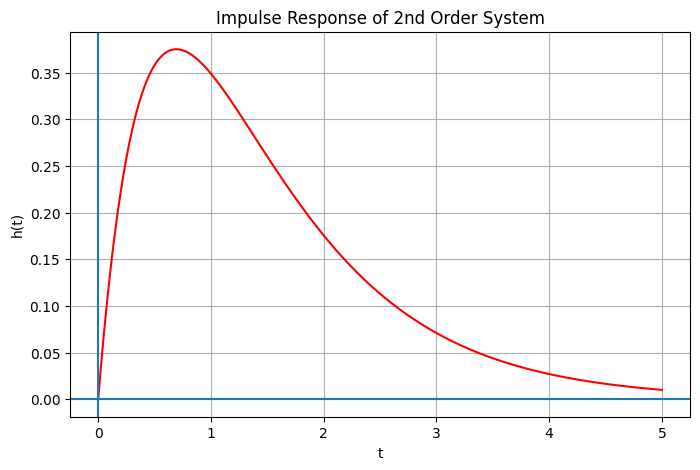

In [17]:
# -----------------------------
# Impulse Response Notebook: 2nd order system
# -----------------------------
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Symbols
# -----------------------------
t = sp.symbols('t', real=True)

# Define system functions
y = sp.Function('y')(t)
x = sp.Function('x')(t)

# -----------------------------
# System differential equation
# -----------------------------
ode = sp.Eq(sp.diff(y,t,2) + 3*sp.diff(y,t) + 2*y, x)
print("System differential equation:")
sp.pprint(ode)

# -----------------------------
# Impulse input
# -----------------------------
print("\nImpulse input:")
print("x(t) = δ(t)")

print("\nThen the system becomes:")
print("d^2/dt^2 h(t) + 3 d/dt h(t) + 2 h(t) = δ(t)")

# -----------------------------
# Auxiliary impulse response
# -----------------------------
h_beta_func = sp.Function('h_beta')(t)

# Auxiliary ODE for h_beta(t)
ode_aux = sp.Eq(sp.diff(h_beta_func,t,2) + 3*sp.diff(h_beta_func,t) + 2*h_beta_func, sp.DiracDelta(t))

# Solve symbolically with initial conditions h_beta(0+)=0, h_beta'(0+)=0
# According to the method: system at rest
h_beta_sol = sp.dsolve(ode_aux, h_beta_func, ics={h_beta_func.subs(t,0):0, h_beta_func.diff(t).subs(t,0):1})

print("\nSolution of auxiliary system h_beta(t):")
sp.pprint(h_beta_sol.rhs)

# -----------------------------
# Here h(t) = h_beta(t) because x(t) is delta
# -----------------------------
h_symbolic = h_beta_sol.rhs

print("\nImpulse response h(t):")
sp.pprint(h_symbolic)

# -----------------------------
# Numeric implementation
# -----------------------------
h_numeric_func = sp.lambdify(t, h_symbolic, 'numpy')

t_vals = np.linspace(0,5,1000)
h_vals = h_numeric_func(t_vals)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(t_vals, h_vals, color='red')  # single curve, red color
plt.axhline(0)
plt.axvline(0)
plt.title("Impulse Response of 2nd Order System")
plt.xlabel("t")
plt.ylabel("h(t)")
plt.grid(True)  # add grid
plt.show()

# Note on the SymPy result for impulse response:

# SymPy uses the convention Heaviside(0) = 1/2 by default. When solving an ODE with DiracDelta(t) and giving initial conditions # exactly at t=0, 
# the jump introduced by the delta function is treated in a way that produces an extra constant term: +1/2 * (exp(-t) - exp(-2*t)).
# This is a consequence of the symmetric handling around t=0 consistent with Heaviside(0) = 1/2 (common in distribution theory / Fourier contexts).
# In engineering / control systems / signals & systems applications, we almost always want the strictly causal response: h(t) = 0    for t < 0
# which corresponds to the expression (exp(-t) - exp(-2*t)) * Heaviside(t) with the convention that Heaviside(0) = 0 or 1 (the exact value at t=0
# has measure zero and does not affect integrals or practical behavior). Therefore we discard the spurious +1/2 term to match the expected
# physical impulse response of a causal LTI system at rest for t < 0.
